# Project 1: Data Science Blog Post

This is a notebook containing the analysis and modelling performed on Business Formation Statistics provided by the US Census Bureau. This project was completed as a requirement for the completion of the Data Scientist nanodegree program on the Udacity platform.

## Part 1: Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
#from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import shap

C:\Users\humur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("bfs_monthly.csv")
df.head()

,sa,naics_sector,series,geo,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,U,TOTAL,BA_BA,US,2026,547443,505240,534850,649160,498776,496832,NaN,NaN,NaN,NaN,NaN,NaN
1,U,NAICS11,BA_BA,US,2026,4687,5048,4676,4871,3366,3129,NaN,NaN,NaN,NaN,NaN,NaN
2,U,NAICS21,BA_BA,US,2026,524,544,593,687,478,509,NaN,NaN,NaN,NaN,NaN,NaN
3,U,NAICS22,BA_BA,US,2026,498,586,581,722,521,562,NaN,NaN,NaN,NaN,NaN,NaN
4,U,NAICS23,BA_BA,US,2026,46834,50799,51361,62652,46995,45469,NaN,NaN,NaN,NaN,NaN,NaN


The dataframe is cleaned by only taking years for which there is data for the full year, thus excluding 2004. Furthermore, adjusted data is dropped since it removes all predictable patterns that might be useful for training. All Business Formations since some of their estimates do not meet publication or privacy standards while also missing data for a territory (see: data dictionary). The dataframe is divided in one for analysis and modelling(2004-2025), and another to create a new scenario for prediction(2026).
Finally, the resulting dataframes only retained data from individual states and not big regions or US totals.

In [3]:
'''INPUT: df= Dataframe of the imported .csv
   OUTPUT: df_clean= clean dataframe to be used for analysis and modelling.
           df_validation= new scenario for prediction by model.
'''

df_full_years = df[(df['year'] > 2004) & (df['sa'] == 'U')] #only full years and unadjusted data to keep predictable patterns for training.

df_full_years = df_full_years[~(df_full_years['series'].str.startswith('BF'))] #unavailable for a territory and some estimates do not meet publication or privacy standards.

cols_to_drop = ['aug', 'sep', 'oct', 'nov', 'dec']
df_full_years.drop(columns=cols_to_drop, inplace=True)

df_clean = df_full_years[df_full_years['year'] != 2026]
df_validation = df_full_years[df_full_years['year'] == 2026] #new scenario

number_cols = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul']
for col in number_cols[:-1]:
    df_clean[col] = df_clean[col].astype('int')
    df_validation[col] = df_validation[col].astype('int')
df_clean[number_cols[-1]] = df_clean[number_cols[-1]].astype('int') 


bigreg = ['US', 'NO', 'MW', 'SO', 'WE']
df_clean = df_clean[~(df_clean['geo'].isin(bigreg))]
df_validation = df_validation[~(df_validation['geo'].isin(bigreg))]


df_clean.info()

<class 'pandas.DataFrame'>
Index: 4368 entries, 1282 to 34109
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   sa            4368 non-null   str  
 1   naics_sector  4368 non-null   str  
 2   series        4368 non-null   str  
 3   geo           4368 non-null   str  
 4   year          4368 non-null   int64
 5   jan           4368 non-null   int64
 6   feb           4368 non-null   int64
 7   mar           4368 non-null   int64
 8   apr           4368 non-null   int64
 9   may           4368 non-null   int64
 10  jun           4368 non-null   int64
 11  jul           4368 non-null   int64
dtypes: int64(8), str(4)
memory usage: 443.6 KB


In [4]:
df_validation[number_cols[:-1]].head()

,jan,feb,mar,apr,may,jun
50,7690,6177,6234,7266,5523,6187
52,952,1180,899,1290,1437,1236
54,11699,12323,12900,16386,13443,14005
56,4137,3492,3719,4644,3562,3899
58,57311,51119,51883,62033,51444,50775


## Part 2: Data Analysis

1. Line graph that gives the volume of each type of business application from 2005 to 2025.

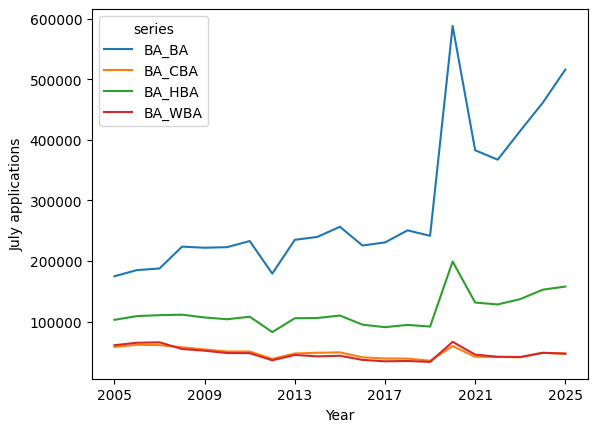

In [5]:
'''INPUT: df_clean
   OUTPUT: line graph.'''

line = df_clean.groupby(['year', 'series'])[number_cols].sum().reset_index()
ax = sns.lineplot(data=line, x='year', y='jul', hue='series')
ax.ticklabel_format(style='plain', axis = 'y')
ax.set_xticks([2004+i for i in range (1, 22, 4)])

plt.xlabel("Year")
plt.ylabel("July applications")
#plt. title("Number of Business applications in July over the years.")

plt.show()

2. Heatmap showing correlation between the values of the months Jan to Jul from **2022-2025**.

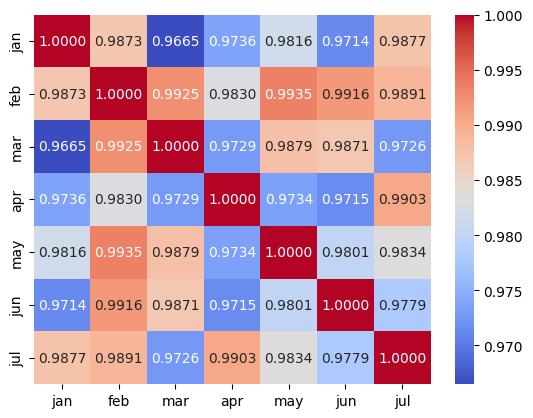

In [7]:
'''INPUT: df_clean
   OUTPUT: Heatmap.'''

sns.heatmap(df_clean[df_clean['year']>=2022][number_cols].corr(), fmt='.4f',annot=True, cmap='coolwarm')
plt.show()

3. Pie chart of percentage of business applications in July for top 7 states in terms of 2025 July applications.

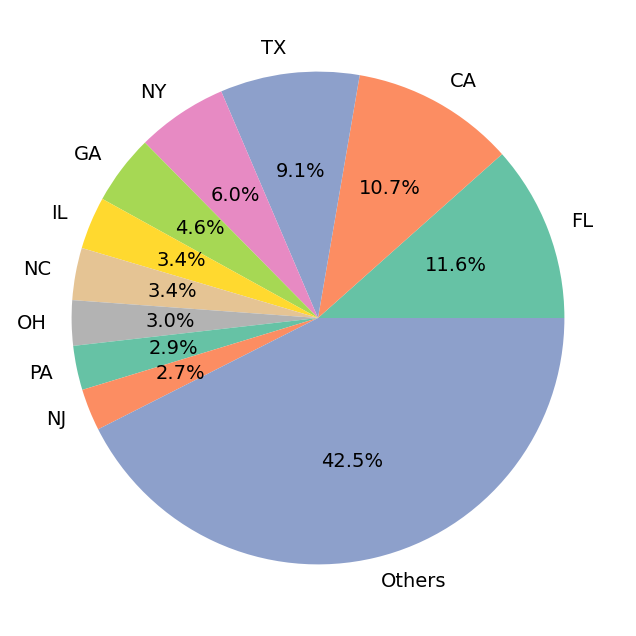

In [8]:
'''INPUT: df_clean
   OUTPUT: pie chart
'''
# making top 10 + the rest table
top_five = df_clean[df_clean['year'] == 2025].groupby(['geo'])['jul'].sum().reset_index()
top_five = top_five.sort_values('jul', ascending=False)

rest = pd.DataFrame({'geo': ['Others'],
                     'jul': [top_five['jul'].iloc[10:].sum()]})

top_five = top_five.iloc[:10]
top_five = pd.concat([top_five, rest])

#plotting
plt.figure(figsize=(8,8))
plt.pie(top_five['jul'], labels=top_five['geo'], textprops= {'fontsize':14},
        autopct='%1.1f%%', colors=sns.color_palette('Set2')) #proclusacademy.com for sns incorporation and fontsize change

#plt. title(label="Percentage of Business Applications by top 10 states for 2025 July applications.",
           #fontdict={"fontsize":16})

plt.show()


4. Bar graph showing total volume of business applications per month(before July) and for each application type for 2026.

C:\Users\humur\AppData\Local\Temp\ipykernel_15876\2641342753.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(number_cols[:-1])


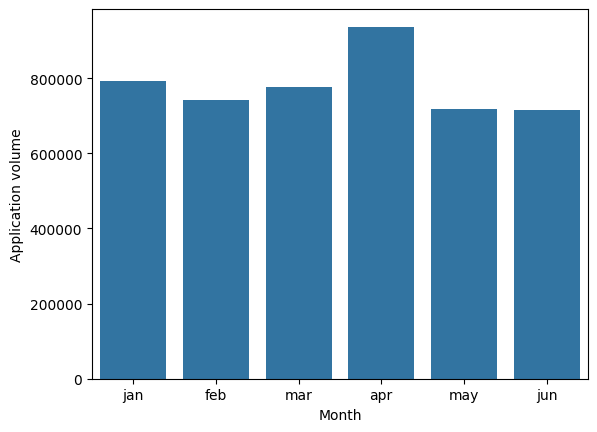

In [9]:
'''INPUT: df_validation
   OUTPUT: bar graph
'''

bar = df_validation[number_cols[:-1]].sum().reset_index()
bar.rename(columns={'index': 'month', 
            0: 'totals'}, inplace=True)
ax1 =sns.barplot(data=bar, x='month', y='totals')
ax1.set_xticklabels(number_cols[:-1])

plt.xlabel("Month")
plt.ylabel("Application volume")
#plt. title("Total volume of Business applications in 2026 (Jan-Jun).")
plt.show()

## Part 3: Modelling

The dataframe __df_clean__ was split into a train set (2005-2021) and a test split(2022-2025). Since this is a time series, this split was preferred over the default train-test split function.

In [10]:
'''Train-test split.'''

train = df_clean[df_clean['year'] <=2021]
test = df_clean[df_clean['year']>=2022]

In [33]:
features = ['series', 'geo', 'year', 'jan', 'feb', 'mar', 'apr', 'may', 'jun']
X_train = train[features]
X_test = test[features]
y_train = train['jul']
y_test = test['jul']

X_train = pd.get_dummies(X_train, columns=['series', 'geo'])
X_test = pd.get_dummies(X_test, columns=['series', 'geo'])

X_train = X_train.astype(int)
X_test = X_test.astype(int)
X = pd.concat([X_train, X_test], axis=0)
sample_ind = 20

X_test.info()

<class 'pandas.DataFrame'>
Index: 832 entries, 1282 to 5542
Data columns (total 63 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   year           832 non-null    int64
 1   jan            832 non-null    int64
 2   feb            832 non-null    int64
 3   mar            832 non-null    int64
 4   apr            832 non-null    int64
 5   may            832 non-null    int64
 6   jun            832 non-null    int64
 7   series_BA_BA   832 non-null    int64
 8   series_BA_CBA  832 non-null    int64
 9   series_BA_HBA  832 non-null    int64
 10  series_BA_WBA  832 non-null    int64
 11  geo_AK         832 non-null    int64
 12  geo_AL         832 non-null    int64
 13  geo_AR         832 non-null    int64
 14  geo_AZ         832 non-null    int64
 15  geo_CA         832 non-null    int64
 16  geo_CO         832 non-null    int64
 17  geo_CT         832 non-null    int64
 18  geo_DC         832 non-null    int64
 19  geo_DE         832 n

In [12]:
'''Calling and fitting model with data.'''
model = RandomForestRegressor(n_estimators=400, max_depth=20, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

The month columns, specifically January, are those with the highest feature importance for this model.

PermutationExplainer explainer: 4369it [25:45,  2.81it/s]                          


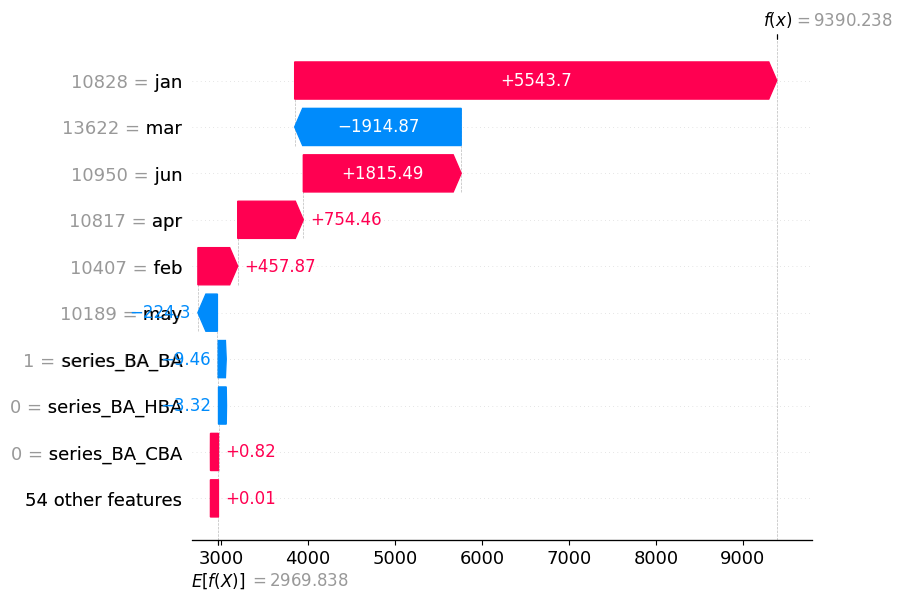

In [ ]:
explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X)



C:\Users\humur\AppData\Local\Temp\ipykernel_15876\3017445420.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


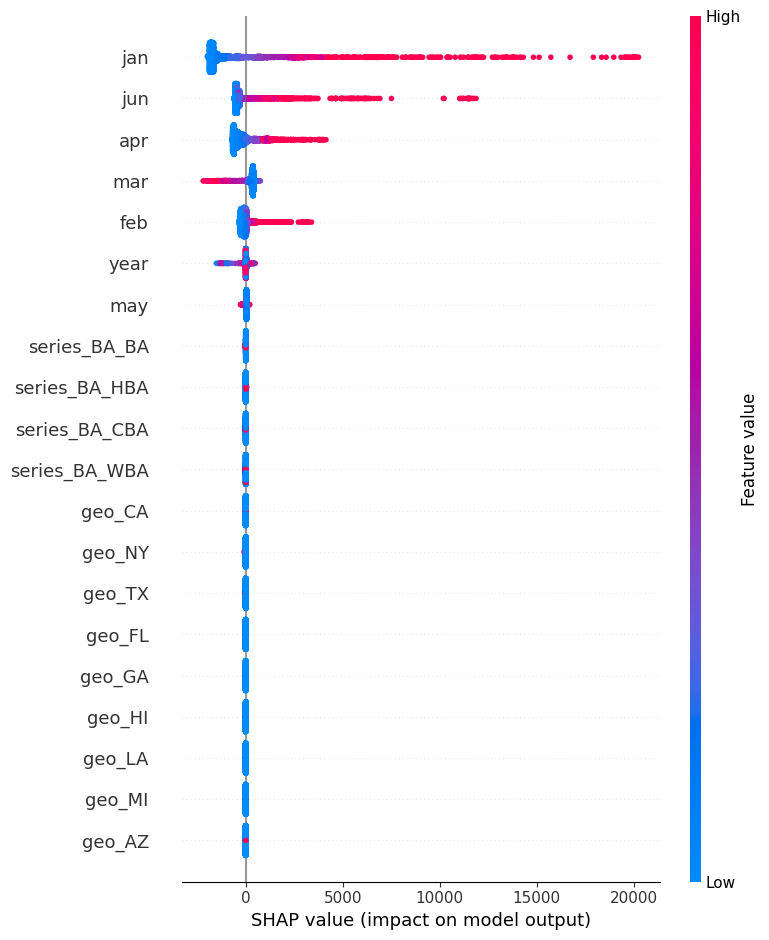

In [32]:
shap.summary_plot(shap_values, X)

In [13]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = root_mean_squared_error(y_train, y_train_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

print(f'Training RMSE: {rmse_train}')
print(f'Testing RMSE: {rmse_test}')

Training RMSE: 866.1938248967708
Testing RMSE: 1254.4042102140613


In [14]:
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)

training_scores = {'Training MAE': mae_train,
                   'Training R^2': r2_train,
                    'Training MAPE': mape_train}

for key, value in training_scores.items():
    print(f'{key}: {value}')



Training MAE: 158.42961648547117
Training R^2: 0.9563032154855762
Training MAPE: 0.06072612039024306


In [15]:
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
mape = mean_absolute_percentage_error(y_test, y_test_pred)

testing_scores = {'Testing MAE': mae,
                   'Testing R^2': r2,
                    'Testing MAPE': mape}

for key, value in testing_scores.items():
    print(f'{key}: {value}')

Testing MAE: 364.7131402182635
Testing R^2: 0.9633778812125886
Testing MAPE: 0.10428766809610063


Despite good evaluation scores, bigger values are all getting the same prediction:

In [56]:
comp = test.copy()
comp['Actuel'] = y_test.values
comp['Predit'] = y_test_pred

feat_months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun']
comp['diff'] = comp['Actuel'] - comp['Predit']
comp['months_avg'] = comp[feat_months].mean(axis=1)

comp[['geo', 'series', 'Actuel', 'Predit', 'diff']].sort_values(['Actuel'], ascending=False).head(20)

,geo,series,Actuel,Predit,diff
1300,FL,BA_BA,59351,41029.037225,18321.962775
2532,FL,BA_BA,55171,41029.037225,14141.962775
3764,FL,BA_BA,50282,41029.037225,9252.962775
1368,TX,BA_BA,48760,41029.037225,7730.962775
1290,CA,BA_BA,47046,41029.037225,6016.962775
3754,CA,BA_BA,46644,41029.037225,5614.962775
4996,FL,BA_BA,46295,41029.037225,5265.962775
2522,CA,BA_BA,45599,41029.037225,4569.962775
2600,TX,BA_BA,42620,41029.037225,1590.962775
4986,CA,BA_BA,35908,40097.850223,-4189.850223


## Part 4: Predictions
Using the 2026 data found in __df_validation__, statistics for July 2026 are predicted by the trained model.

In [17]:
'''OUTPUT: df_validation
   INPUT: new_scenario = dataframe with only necessary features for training.
'''
new_scenario = df_validation.copy()[features]
new_scenario = pd.get_dummies(new_scenario, columns=['series', 'geo'])

new_scenario.info()

<class 'pandas.DataFrame'>
Index: 208 entries, 50 to 614
Data columns (total 63 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   year           208 non-null    int64
 1   jan            208 non-null    int64
 2   feb            208 non-null    int64
 3   mar            208 non-null    int64
 4   apr            208 non-null    int64
 5   may            208 non-null    int64
 6   jun            208 non-null    int64
 7   series_BA_BA   208 non-null    bool 
 8   series_BA_CBA  208 non-null    bool 
 9   series_BA_HBA  208 non-null    bool 
 10  series_BA_WBA  208 non-null    bool 
 11  geo_AK         208 non-null    bool 
 12  geo_AL         208 non-null    bool 
 13  geo_AR         208 non-null    bool 
 14  geo_AZ         208 non-null    bool 
 15  geo_CA         208 non-null    bool 
 16  geo_CO         208 non-null    bool 
 17  geo_CT         208 non-null    bool 
 18  geo_DC         208 non-null    bool 
 19  geo_DE         208 non-

In [18]:
july_pred_ns = model.predict(new_scenario)

In [ ]:
predictions = df_validation.copy()

predictions['jul'] = july_pred_ns


,geo,series,jan,feb,mar,apr,may,jun,jul
50,AL,BA_BA,7690,6177,6234,7266,5523,6187,6388.691339
52,AK,BA_BA,952,1180,899,1290,1437,1236,1185.313511
54,AZ,BA_BA,11699,12323,12900,16386,13443,14005,13397.800147
56,AR,BA_BA,4137,3492,3719,4644,3562,3899,3940.402307
58,CA,BA_BA,57311,51119,51883,62033,51444,50775,41029.037225
60,CO,BA_BA,14603,12634,14600,19148,14173,14841,15093.748871
62,CT,BA_BA,4776,4532,5010,6099,4432,4473,5061.369190
64,DE,BA_BA,5258,5128,5072,6330,4469,4761,5435.071377
66,DC,BA_BA,1372,1238,1323,1696,1285,1280,1426.105544
68,FL,BA_BA,54003,59768,67215,83425,61952,59748,41029.037225


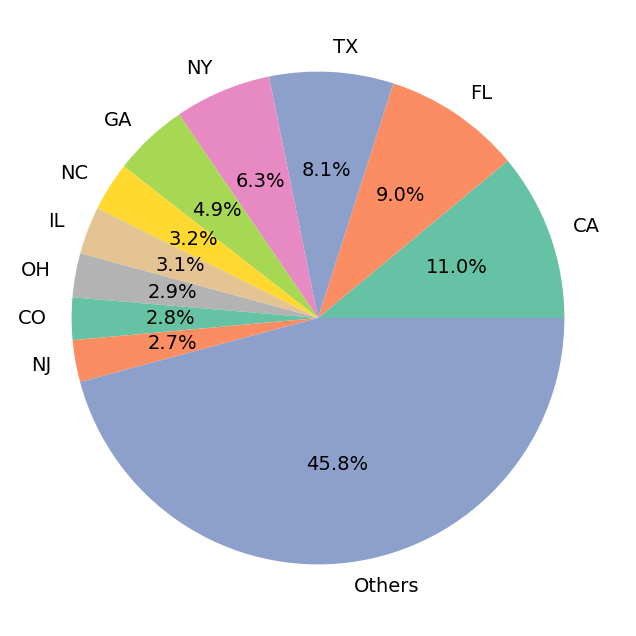

In [61]:
'''INPUT: predictions = copy of df_validation with predictions for July 2026.
   OUTPUT: pie chart
'''
# making top 10 + the rest table
top_five = predictions.groupby(['geo'])['jul'].sum().reset_index()
top_five = top_five.sort_values('jul', ascending=False)

rest = pd.DataFrame({'geo': ['Others'],
                     'jul': [top_five['jul'].iloc[10:].sum()]})

top_five = top_five.iloc[:10]
top_five = pd.concat([top_five, rest])

#plotting
plt.figure(figsize=(8,8))
plt.pie(top_five['jul'], labels=top_five['geo'], textprops= {'fontsize':14},
        autopct='%1.1f%%', colors=sns.color_palette('Set2')) #proclusacademy.com for sns incorporation and fontsize change

#plt. title(label="Percentage of Business Applications by top 10 states for 2025 July applications.",
           #fontdict={"fontsize":16})

plt.show()


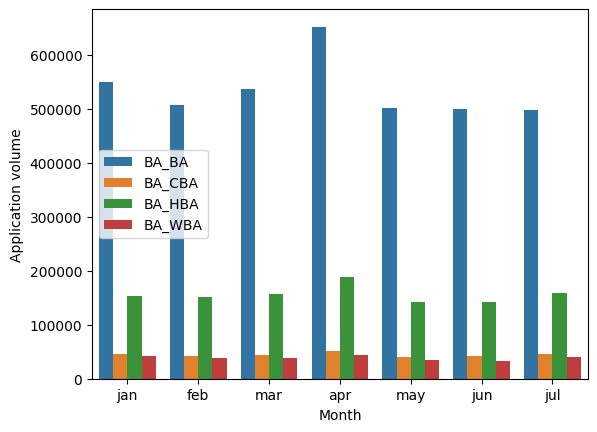

In [ ]:
'''INPUT: df_validation
   OUTPUT: bar graph
'''

bar = predictions.melt(id_vars=['series'], value_vars= number_cols, var_name='month', value_name= 'totals')
bar = bar.groupby(['series', 'month'])[['totals']].sum().reset_index()
ax1 =sns.barplot(data=bar, x='month', y='totals', hue='series', order= number_cols)


plt.xlabel("Month")
plt.ylabel("Application volume")
plt.legend(loc='center left')
#plt. title("Total volume of Business applications in 2026 (Jan-Jun).")
plt.show()